In [1]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

In [2]:
df = pd.read_csv('./data_root/heart_attack_prediction_dataset.csv')

In [3]:
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [4]:
df.rename(columns = {'BMI': 'IMC'}, inplace= True)

In [5]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,IMC,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [7]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,IMC,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


In [8]:
df.isnull().sum()

Patient ID                         0
Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
IMC                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Country                            0
Continent                          0
Hemisphere                         0
Heart Attack Risk                  0
dtype: int64

In [9]:
df['is_Male'] = df['Sex'].apply(lambda x: 1 if x == 'Male' else 0)
df = df.drop(columns=['Patient ID', 'Hemisphere', 'Sex', 'Physical Activity Days Per Week', 'Continent'])
df.head()

# Trocamos o Male para o valor 1 e Famale para o valor 0

,Age,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Medication Use,Stress Level,Sedentary Hours Per Day,Income,IMC,Triglycerides,Sleep Hours Per Day,Country,Heart Attack Risk,is_Male
0,67,208,158/88,72,0,0,1,0,0,4.168189,...,0,9,6.615001,261404,31.251233,286,6,Argentina,0,1
1,21,389,165/93,98,1,1,1,1,1,1.813242,...,0,1,4.963459,285768,27.194973,235,7,Canada,0,1
2,21,324,174/99,72,1,0,0,0,0,2.078353,...,1,9,9.463426,235282,28.176571,587,4,France,0,0
3,84,383,163/100,73,1,1,1,0,1,9.828130,...,0,9,7.648981,125640,36.464704,378,4,Canada,0,1
4,66,318,91/88,93,1,1,1,1,0,5.804299,...,0,6,1.514821,160555,21.809144,231,5,Thailand,0,1


In [10]:
df_box1 = df[['Exercise Hours Per Week', 'Previous Heart Problems','Sedentary Hours Per Day','IMC']]
df_box2 = df[['Heart Rate','Cholesterol','Triglycerides', 'Age']]

# Criamos dois boxplot para identifcar outliers, um dos valores inteiros e um para os floats

In [11]:
px.box(df_box1)

In [12]:
px.box(df_box2)

<Axes: >

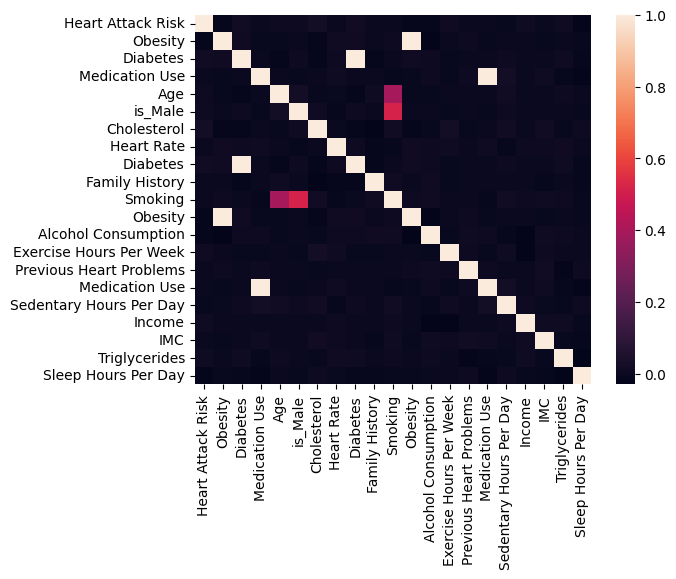

In [13]:
import seaborn as sns

sns.heatmap(df[['Heart Attack Risk','Obesity','Diabetes', 'Medication Use','Age', 
                'is_Male','Cholesterol', 'Heart Rate', 'Diabetes',
       'Family History', 'Smoking', 'Obesity', 'Alcohol Consumption',
       'Exercise Hours Per Week','Previous Heart Problems',
       'Medication Use', 'Sedentary Hours Per Day', 'Income',
       'IMC', 'Triglycerides',
       'Sleep Hours Per Day',]].corr())

#Heatmap para identicar melhor os dados e outliers

### Detecção de outliers 
Identificamos que nesse dataset não há outliers que estejam explícitos. Fizemos gráficos de boxplot para analisar a distribuiçao dos dados e nao havia outliers presentes. 

### Insights 
Colesterol tem dados maiores de 350, o que seria um colesterol muito alto do padrao. Cogitamos reduzir porëm podemos tirar reflexoes futuras sobre o risco de ataque cardíaco. 

Existem relaçao com Idade e pessoas fumantes e um relaçao baixa mas consideravel com genero e risco de ataque cardiaco, porem os dados considerados sao com vários publicos com números consideraveis para diferentes regioes e genero dificultando dizer ao certo.

In [14]:
grouped_data = df.groupby('Age')['Heart Attack Risk'].sum().reset_index()

fig = px.line(
    grouped_data, 
    x='Age', 
    y='Heart Attack Risk', 
    labels={'Age Group': 'Faixa Etária', 'Heart Attack Risk': 'Risco Cardíaco'},
    title='Distribuição de Risco Cardíaco por Faixa Etária'
)

# Exibir o gráfico
fig.show()


In [15]:
# Separando a coluna 'Blood Pressure' em 'Systolic' e 'Diastolic'
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic'] = pd.to_numeric(df['Systolic'])
df['Diastolic'] = pd.to_numeric(df['Diastolic'])

# Agrupando por colesterol e somando o risco de ataque cardíaco
cholesterol_risk = df.groupby('Cholesterol').agg({
    'Systolic': 'mean', 
    'Diastolic': 'mean',  
    'Heart Attack Risk': 'sum' 
}).reset_index()

# Gráfico de dispersão para Cholesterol vs Systolic Pressure
fig1 = px.scatter(cholesterol_risk, x='Heart Attack Risk', y='Systolic',
                   color='Cholesterol', 
                  labels={'Cholesterol': 'Nivel de Colesterol', 'Systolic': 'Pressão arterial sistólica', 'Heart Attack Risk': 'Risco de ataque cardíaco'},
                  title='Colesterol vs Pressão arterial sistólica')

# Gráfico de dispersão para Cholesterol vs Diastolic Pressure
fig2 = px.scatter(cholesterol_risk, x='Heart Attack Risk', y='Diastolic',
                    color='Cholesterol', 
                  labels={'Cholesterol': 'Nivel de Colesterol', 'Diastolic': 'Pressão Arterial Diastólica', 'Heart Attack Risk': 'Risco de ataque cardíaco'},
                  title='Colesterol vs Pressão Arterial Diastólica')

fig1.show()
fig2.show()

In [16]:
bins = [0, 60, 70, 80, 150]  
labels = ['Low', 'Normal', 'High', 'Very High'] 

# Criar uma nova coluna para a faixa de frequência cardíaca
df['Heart Rate Group'] = pd.cut(df['Heart Rate'], bins=bins, labels=labels, right=False)

# Agrupar pela faixa de frequência cardíaca e somar o risco de ataque cardíaco
heart_rate_risk = df.groupby('Heart Rate Group')['Heart Attack Risk'].sum().reset_index()
fig = px.bar(heart_rate_risk, 
             x='Heart Rate Group', 
             y='Heart Attack Risk',
             labels={'Heart Rate Group': 'Heart Rate Group', 'Heart Attack Risk': 'Risco de ataque cardiaco'},
             title='Relação entre Batimento cardiaco e Risco de ataque cardiaco')

fig.show()

C:\Users\garin\AppData\Local\Temp\ipykernel_28008\3166570976.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Outra coisa que analisamos foi o salário, que parece não ter muita relação pois afeta a classe mais alta e o uso do medicamento parece não ter afeito no risco do ataque cardíaco ou não foi documentado na base de dados após o uso ou o tempo de consumo.

In [17]:
#  remove Blood pressure pois foi separado em 2 valores diferentes Systolic e Diastolic
df.drop(['Blood Pressure'], axis=1, inplace=True)

In [18]:
df

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Income,IMC,Triglycerides,Sleep Hours Per Day,Country,Heart Attack Risk,is_Male,Systolic,Diastolic,Heart Rate Group
0,67,208,72,0,0,1,0,0,4.168189,Average,...,261404,31.251233,286,6,Argentina,0,1,158,88,High
1,21,389,98,1,1,1,1,1,1.813242,Unhealthy,...,285768,27.194973,235,7,Canada,0,1,165,93,Very High
2,21,324,72,1,0,0,0,0,2.078353,Healthy,...,235282,28.176571,587,4,France,0,0,174,99,High
3,84,383,73,1,1,1,0,1,9.828130,Average,...,125640,36.464704,378,4,Canada,0,1,163,100,High
4,66,318,93,1,1,1,1,0,5.804299,Unhealthy,...,160555,21.809144,231,5,Thailand,0,1,91,88,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,60,121,61,1,1,1,0,1,7.917342,Healthy,...,235420,19.655895,67,7,Thailand,0,1,94,76,Normal
8759,28,120,73,1,0,0,1,0,16.558426,Healthy,...,217881,23.993866,617,9,Canada,0,0,157,102,High
8760,47,250,105,0,1,1,1,1,3.148438,Average,...,36998,35.406146,527,4,Brazil,1,1,161,75,Very High
8761,36,178,60,1,0,1,0,0,3.789950,Unhealthy,...,209943,27.294020,114,8,Brazil,0,1,119,67,Normal


In [19]:
scaler = MinMaxScaler()
df_not_normalize = df.copy()

columns_to_normalize= ['Age', 'Cholesterol', 'Exercise Hours Per Week', 'Sedentary Hours Per Day', "Income", "IMC", "Triglycerides", "Sleep Hours Per Day", "Systolic", "Diastolic"]
# Aplicando a normalização nas colunas numericas com frequencia
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

df.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Income,IMC,Triglycerides,Sleep Hours Per Day,Country,Heart Attack Risk,is_Male,Systolic,Diastolic,Heart Rate Group
0,0.680556,0.314286,72,0,0,1,0,0,0.208326,Average,...,0.862268,0.602363,0.332468,0.333333,Argentina,0,1,0.755556,0.56,High
1,0.041667,0.960714,98,1,1,1,1,1,0.090557,Unhealthy,...,0.949316,0.417945,0.266234,0.500000,Canada,0,1,0.833333,0.66,Very High
2,0.041667,0.728571,72,1,0,0,0,0,0.103815,Healthy,...,0.768939,0.462573,0.723377,0.000000,France,0,0,0.933333,0.78,High
3,0.916667,0.939286,73,1,1,1,0,1,0.491376,Average,...,0.377210,0.839394,0.451948,0.000000,Canada,0,1,0.811111,0.80,High
4,0.666667,0.707143,93,1,1,1,1,0,0.290147,Unhealthy,...,0.501954,0.173077,0.261039,0.166667,Thailand,0,1,0.011111,0.56,Very High


## Insights
Normalizar os dados para modelos como KNN ou outros é uma boa prática mas para Random forest que seria o mais ideal para esse dataset não precisa. Entretanto, mesmo assim todas as colunas númericas agora tem a mesma frequência para melhor uso em futuras analises. Iremos verificar nos proximos passos se a acuracia muda.

In [20]:
df['Diet'].unique()

# Verificando o tipo tipo dos dados e o nome deles

array(['Average', 'Unhealthy', 'Healthy'], dtype=object)

In [21]:
label_encoder = LabelEncoder()
df['Diet'] = label_encoder.fit_transform(df['Diet'])

df_not_normalize['Diet'] = label_encoder.fit_transform(df['Diet'])

(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Transformando eles em númericos utilizando Label Encoder
# Printando os antigos nomes com os novos números, mas estará comentado abaixo para uma melhor visualização

# Average: 0, Healthy: 1, Unhealthy: 2 

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}

In [22]:
df.head()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Income,IMC,Triglycerides,Sleep Hours Per Day,Country,Heart Attack Risk,is_Male,Systolic,Diastolic,Heart Rate Group
0,0.680556,0.314286,72,0,0,1,0,0,0.208326,0,...,0.862268,0.602363,0.332468,0.333333,Argentina,0,1,0.755556,0.56,High
1,0.041667,0.960714,98,1,1,1,1,1,0.090557,2,...,0.949316,0.417945,0.266234,0.500000,Canada,0,1,0.833333,0.66,Very High
2,0.041667,0.728571,72,1,0,0,0,0,0.103815,1,...,0.768939,0.462573,0.723377,0.000000,France,0,0,0.933333,0.78,High
3,0.916667,0.939286,73,1,1,1,0,1,0.491376,0,...,0.377210,0.839394,0.451948,0.000000,Canada,0,1,0.811111,0.80,High
4,0.666667,0.707143,93,1,1,1,1,0,0.290147,2,...,0.501954,0.173077,0.261039,0.166667,Thailand,0,1,0.011111,0.56,Very High
